# Comprehensive Text EDA - IMDB Movie Reviews Dataset

Bộ dữ liệu: IMDB Dataset gồm 50,000 bài đánh giá phim với 2 lớp: **positive** và **negative**



## Nội dung phân tích:
- **Part A**: Phân phối độ dài văn bản (số từ, số ký tự) theo nhãn lớp + Mann-Whitney U test
- **Part B**: Trực quan hóa từ phổ biến, Top-50 từ xuất hiện nhiều nhất và Type-Token Ratio (TTR)
- **Part C**: Phân tích phân phối Zipf (log-log plot)

## Library Installation and Configuration

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.stats import mannwhitneyu, linregress
from wordcloud import WordCloud
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Đường dẫn dữ liệu
DATA_PATH = '../data/raw/text/IMDB Dataset.csv'

## Load and Preprocess Data

In [2]:
# Đọc dữ liệu
df = pd.read_csv(DATA_PATH)

print(f'Thông tin dataset:')
print(f'Tổng số mẫu: {len(df)}')
print(f'Số cột: {len(df.columns)}')
print(f'Tên cột: {list(df.columns)}\n')
print('Phân bố nhãn:')
print(df['sentiment'].value_counts())
print()

Thông tin dataset:
Tổng số mẫu: 50000
Số cột: 2
Tên cột: ['review', 'sentiment']

Phân bố nhãn:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64



In [3]:
print('5 mẫu đầu tiên:')
df.head()

5 mẫu đầu tiên:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Part A - Phân phối Độ dài Văn bản + Mann-Whitney U Test

Phần này tính và trực quan hóa phân phối độ dài văn bản (số từ, số ký tự) theo từng nhãn lớp **trên dữ liệu thô**, đồng thời thực hiện kiểm định Mann-Whitney U để xác định sự khác biệt có ý nghĩa thống kê.

### A.1 Phân phối độ dài văn bản

In [4]:
# Tính số từ và số ký tự trên văn bản gốc
df['word_count'] = df['review'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['review'].apply(lambda x: len(str(x)))

In [5]:
CLASSES = df['sentiment'].unique()
print(f'Lớp nhãn: {CLASSES}')
# Thống kê theo từng lớp
stats_by_class = df.groupby('sentiment').agg({
    'word_count': ['count', 'mean', 'std', 'median', 'min', 'max'],
    'char_count': ['count', 'mean', 'std', 'median', 'min', 'max']
}).round(2)

print(stats_by_class)

word_count_positive = df[df['sentiment'] == 'positive']['word_count']
word_count_negative = df[df['sentiment'] == 'negative']['word_count']
char_count_positive = df[df['sentiment'] == 'positive']['char_count']
char_count_negative = df[df['sentiment'] == 'negative']['char_count']

mean_word_positive = word_count_positive.mean()
mean_word_negative = word_count_negative.mean()
mean_char_positive = char_count_positive.mean()
mean_char_negative = char_count_negative.mean()

Lớp nhãn: ['positive' 'negative']
          word_count                                  char_count           \
               count    mean     std median min   max      count     mean   
sentiment                                                                   
negative       25000  229.46  164.95  174.0   4  1522      25000  1294.06   
positive       25000  232.85  177.50  172.0  10  2470      25000  1324.80   

                                      
               std median min    max  
sentiment                             
negative    945.89  973.0  32   8969  
positive   1031.49  968.0  65  13704  


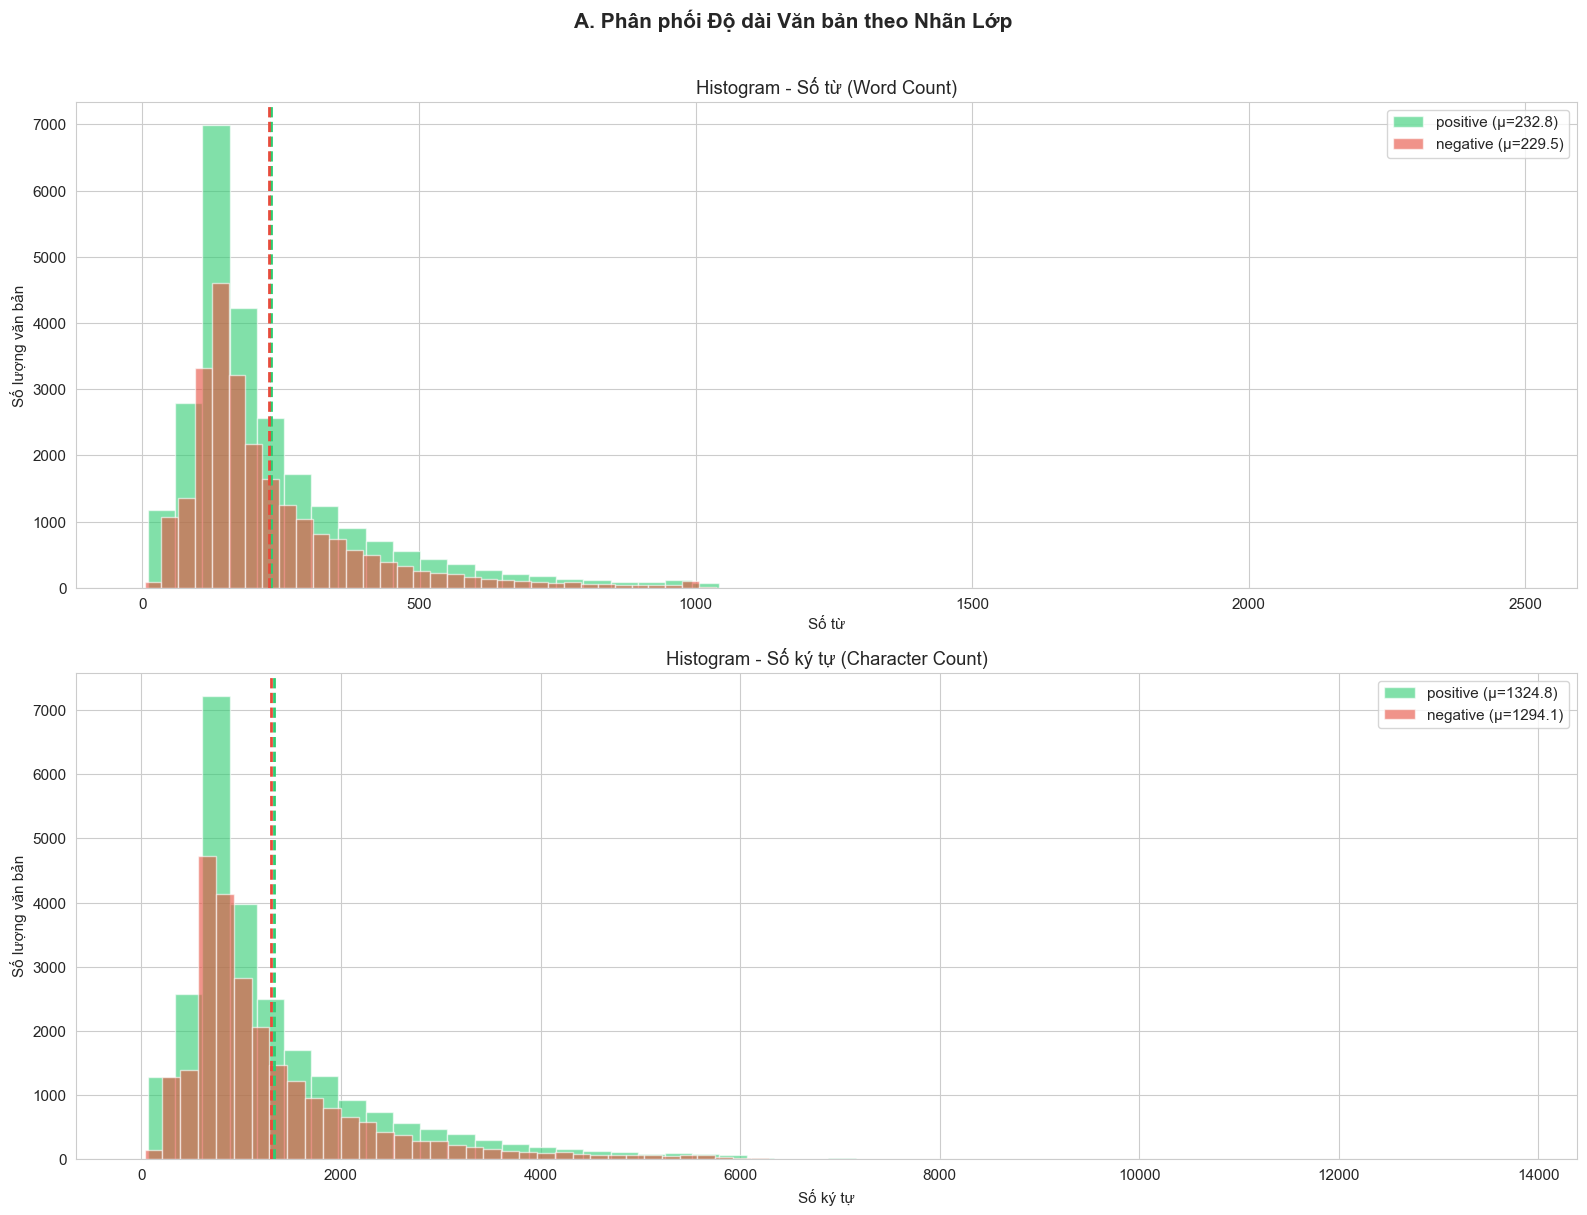

In [6]:
# TRỰC QUAN HÓA PHÂN PHỐI ĐỘ DÀI VĂN BẢN
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('A. Phân phối Độ dài Văn bản theo Nhãn Lớp', fontsize=15, fontweight='bold', y=1.01)

colors = {'positive': '#2ecc71', 'negative': '#e74c3c'}

#  Histogram số từ 
ax1 = axes[0]
for sentiment in CLASSES:
    data = df[df['sentiment'] == sentiment]['word_count']
    ax1.hist(data, bins=50, alpha=0.6, color=colors[sentiment], label=f'{sentiment} (μ={data.mean():.1f})', edgecolor='white')
ax1.axvline(mean_word_positive, color=colors['positive'], linestyle='--', linewidth=2)
ax1.axvline(mean_word_negative, color=colors['negative'], linestyle='--', linewidth=2)
ax1.set_title('Histogram - Số từ (Word Count)')
ax1.set_xlabel('Số từ')
ax1.set_ylabel('Số lượng văn bản')
ax1.legend()

#  Histogram số ký tự 
ax2 = axes[1]
for sentiment in CLASSES:
    data = df[df['sentiment'] == sentiment]['char_count']
    ax2.hist(data, bins=50, alpha=0.6, color=colors[sentiment], label=f'{sentiment} (μ={data.mean():.1f})', edgecolor='white')
ax2.axvline(mean_char_positive, color=colors['positive'], linestyle='--', linewidth=2)
ax2.axvline(mean_char_negative, color=colors['negative'], linestyle='--', linewidth=2)
ax2.set_title('Histogram - Số ký tự (Character Count)')
ax2.set_xlabel('Số ký tự')
ax2.set_ylabel('Số lượng văn bản')
ax2.legend()

plt.tight_layout()
plt.show()

* **Nhận xét:** Các biểu đồ cho thấy dữ liệu lệch phải mạnh và chứa nhiều điểm ngoại lệ outliers. Giá trị trung bình của lớp *positive* nhỉnh hơn lớp *negative* một chút ở cả số từ và số ký tự.


### A.2 Kiểm định Mann-Whitney U test
**Mann–Whitney U test** là một kiểm định thống kê phi tham số dùng để so sánh 2 nhóm độc lập xem chúng có khác nhau về phân bố hay không.

- H0: Không có sự khác biệt về độ dài văn bản giữa 2 lớp
- H1: Có sự khác biệt về độ dài văn bản giữa 2 lớp
- Mức ý nghĩa α = 0.05

In [7]:
# Kiểm định cho số từ (word count)
stat_word, p_value_word = mannwhitneyu(word_count_positive, word_count_negative, alternative='two-sided')
print(f'Kiểm định cho SỐ TỪ (Word Count):')
print(f'    - U-statistic: {stat_word:,.0f}')
print(f'    - p-value: {p_value_word:.2e}')

# Kiểm định cho số ký tự (char count)
stat_char, p_value_char = mannwhitneyu(char_count_positive, char_count_negative, alternative='two-sided')
print(f'\nKiểm định cho SỐ KÝ TỰ (Character Count):')
print(f'    - U-statistic: {stat_char:,.0f}')
print(f'    - p-value: {p_value_char:.2e}')

Kiểm định cho SỐ TỪ (Word Count):
    - U-statistic: 308,970,265
    - p-value: 2.87e-02

Kiểm định cho SỐ KÝ TỰ (Character Count):
    - U-statistic: 310,302,357
    - p-value: 1.73e-01


* **Kết quả kiểm định (Mann-Whitney U):**
    * **Số từ (Word Count):** p-value = 0.0287 < 0.05 => **Có** sự khác biệt mang ý nghĩa thống kê giữa hai lớp.
    * **Số ký tự (Character Count):** p-value = 0.173 > 0.05 => **Không có** sự khác biệt mang ý nghĩa thống kê.
* **Kết luận:** Dù số từ có sự khác biệt về mặt thống kê, nhưng độ chênh lệch thực tế rất nhỏ. Do đó, độ dài văn bản là một đặc trưng khá yếu và không mang lại nhiều giá trị để phân biệt cảm xúc (tích cực/tiêu cực) cho bài toán.


## Part B - Trực quan hóa các từ phổ biến, Top-50 Từ và Type-Token Ratio (TTR)

Phần này trực quan hóa các từ phổ biến bằng Word Cloud, xác định top-50 từ phổ biến nhất theo từng lớp và tính Type-Token Ratio để đánh giá độ phong phú từ vựng.

### B.1 Trực quan hóa các từ phổ biến

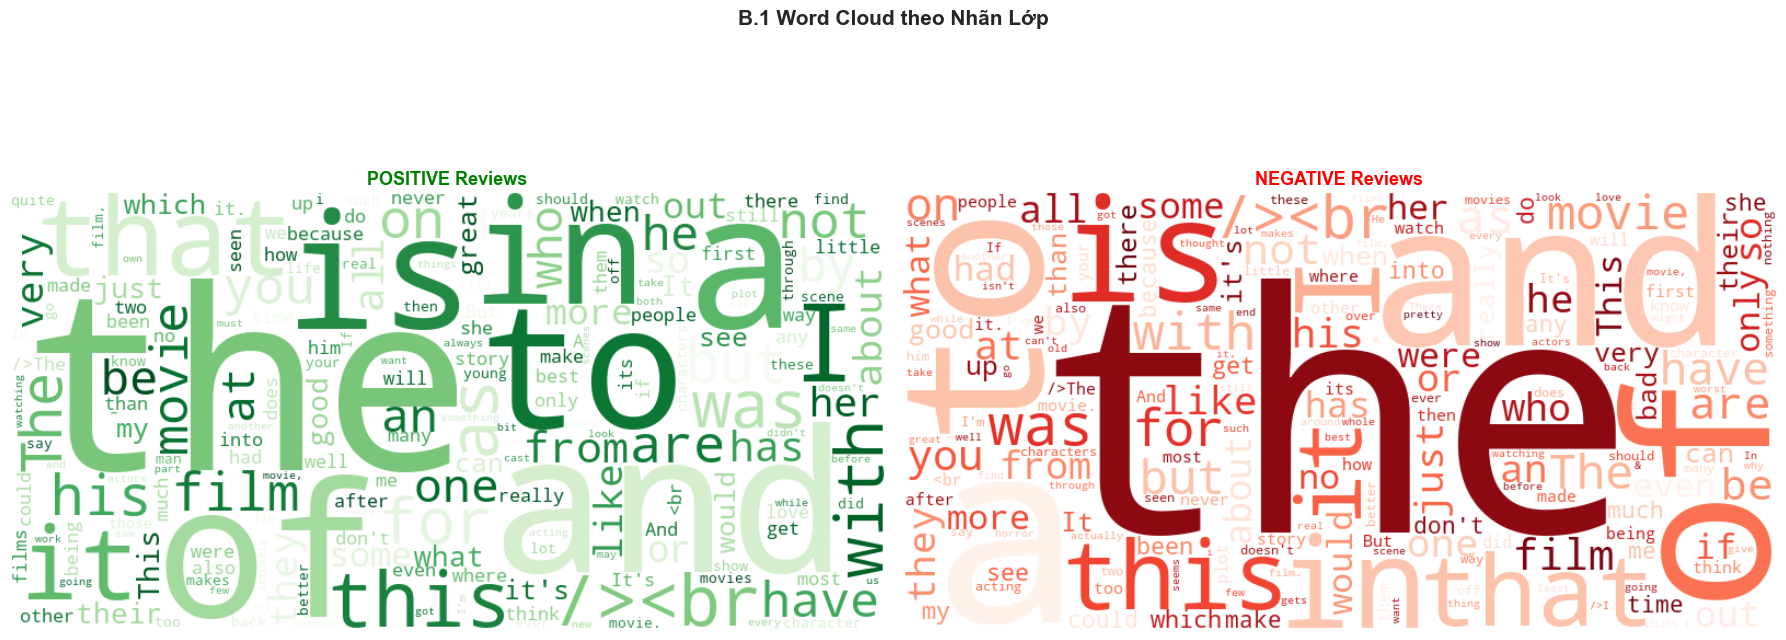

In [8]:
def get_word_freq(texts, remove_stopwords=True):
    """Đếm tần suất trực tiếp trên raw text."""
    counter = Counter()
    for text in texts:
        words = str(text).split()   # tách từ
        counter.update(words)
    return counter

# Khởi tạo word_freq_positive và word_freq_negative (giữ nguyên biến)
word_freq_positive = get_word_freq(df[df['sentiment'] == 'positive']['review'])
word_freq_negative = get_word_freq(df[df['sentiment'] == 'negative']['review'])

# vẽ word cloud cho 2 lớp nhãn
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('B.1 Word Cloud theo Nhãn Lớp', fontsize=15, fontweight='bold')

wc_positive = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Greens',
    max_words=200,
    collocations=False
).generate_from_frequencies(word_freq_positive)

wc_negative = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Reds',
    max_words=200,
    collocations=False
).generate_from_frequencies(word_freq_negative)

axes[0].imshow(wc_positive, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('POSITIVE Reviews', fontsize=13, color='green', fontweight='bold')

axes[1].imshow(wc_negative, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('NEGATIVE Reviews', fontsize=13, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

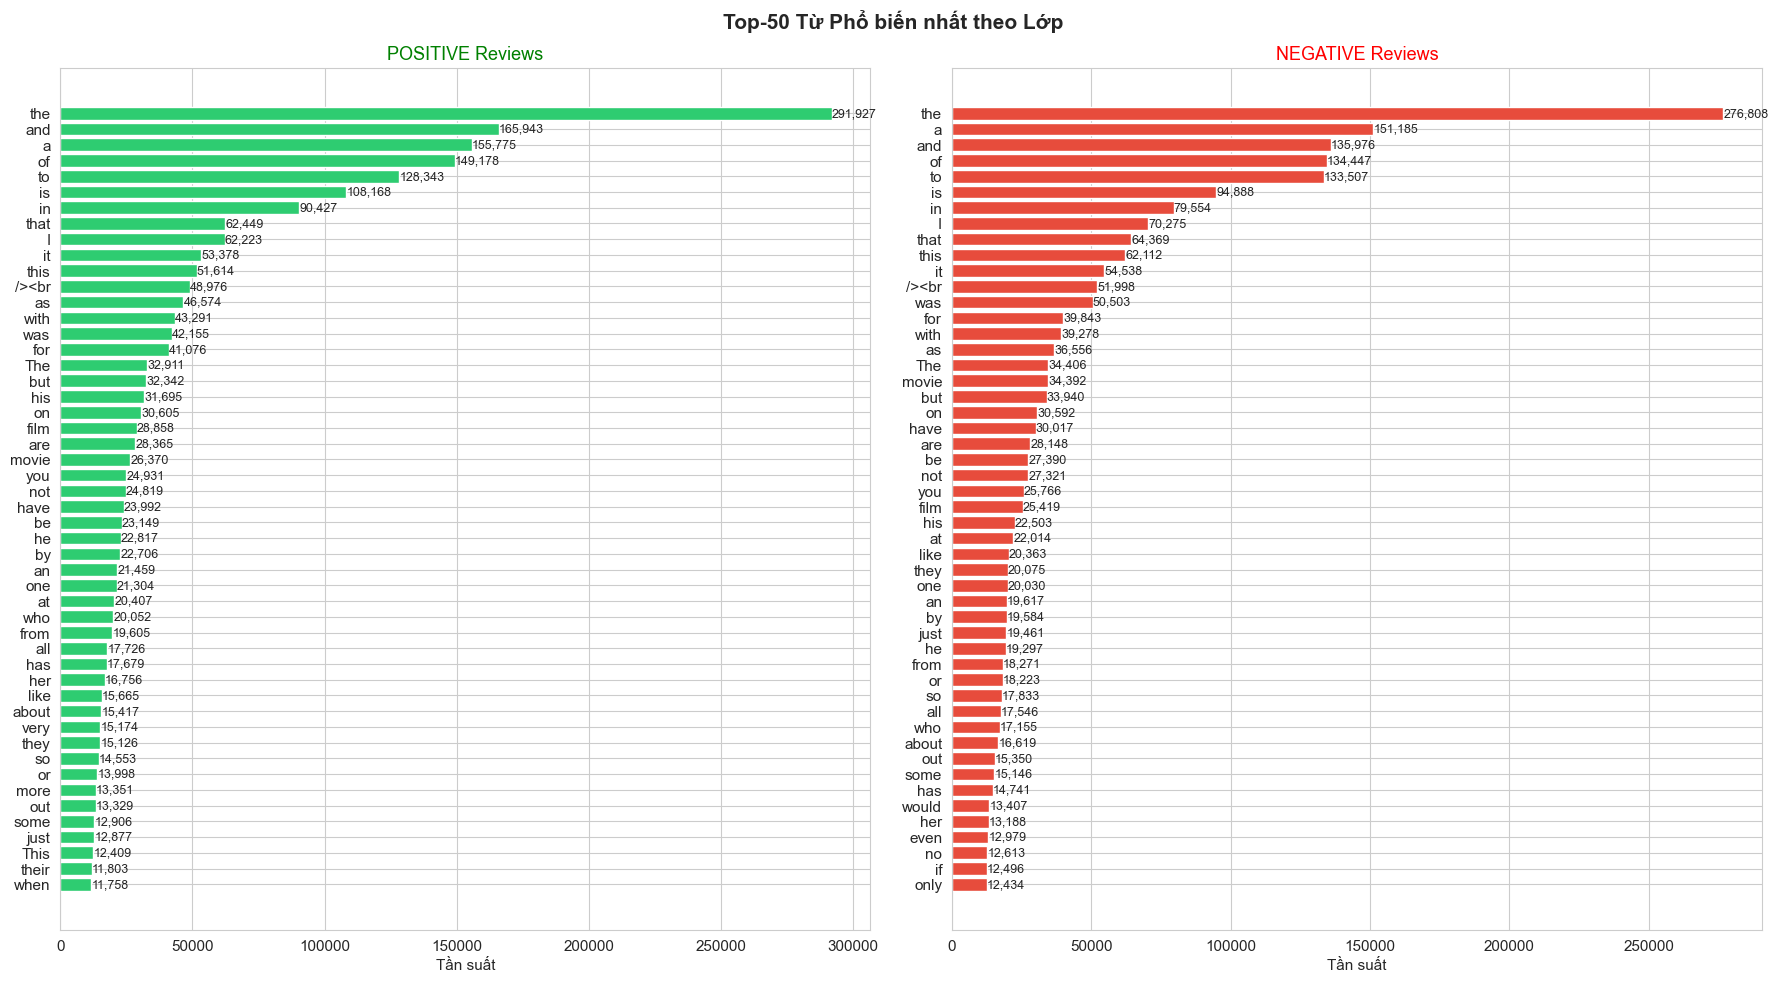

In [9]:
#Top 50 từ phổ biến theo từng lớp
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.suptitle('Top-50 Từ Phổ biến nhất theo Lớp', fontsize=15, fontweight='bold')

# Top-50 Positive
ax1 = axes[0]
top50_pos = word_freq_positive.most_common(50)
words_pos = [w for w, c in top50_pos][::-1]
counts_pos = [c for w, c in top50_pos][::-1]
ax1.barh(words_pos, counts_pos, color='#2ecc71', edgecolor='white')
ax1.set_title('POSITIVE Reviews', fontsize=13, color='green')
ax1.set_xlabel('Tần suất')
for i, (word, count) in enumerate(zip(words_pos, counts_pos)):
    ax1.text(count + 50, i, f'{count:,}', va='center', fontsize=9)

# Top-50 Negative
ax2 = axes[1]
top50_neg = word_freq_negative.most_common(50)
words_neg = [w for w, c in top50_neg][::-1]
counts_neg = [c for w, c in top50_neg][::-1]
ax2.barh(words_neg, counts_neg, color='#e74c3c', edgecolor='white')
ax2.set_title('NEGATIVE Reviews', fontsize=13, color='red')
ax2.set_xlabel('Tần suất')
for i, (word, count) in enumerate(zip(words_neg, counts_neg)):
    ax2.text(count + 50, i, f'{count:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Nhận xét**
* **Sự thống trị của Stopwords:** Cả hai lớp **Positive** và **Negative** đều bị chiếm ưu thế bởi các hư từ (stopwords) như: *the, and, a, of, to, is, in...* Điều này khiến biểu đồ Word Cloud của hai lớp trông rất giống nhau và chưa làm nổi bật được sắc thái biểu cảm riêng biệt của từng lớp.
* **Nhiễu dữ liệu:** Xuất hiện các ký tự rác từ quá trình bóc tách dữ liệu web như `/><br`, `it's`, `don't`. Điều này cho thấy dữ liệu cần được làm sạch kỹ hơn (loại bỏ HTML tags, xử lý viết tắt).
* **Đặc trưng tập dữ liệu:** Các danh từ chung như *movie, film, one, like* xuất hiện dày đặc ở cả hai phía. Đây là đặc điểm chung của dữ liệu đánh giá phim.

### B.2 Type-Token Ratio (TTR)

**Type-Token Ratio (TTR)** là một chỉ số phổ biến trong NLP dùng để đánh giá độ phong phú của từ vựng trong một đoạn văn bản.
Công thức:
- TTR = (Số lượng Type) / (Số lượng Token)

Theo đó: 
- TTR càng cao (gần 1): Văn bản có vốn từ vựng rất đa dạng, phong phú, ít lặp lại từ ngữ.
- TTR càng thấp (gần 0): Văn bản lặp đi lặp lại một số từ nhất định, vốn từ kém đa dạng.

In [10]:
def calculate_ttr(texts):
    """
    Tính Type-Token Ratio cho danh sách văn bản THÔ.
    Returns: (TTR, total_tokens, unique_types)
    """
    all_words = []
    for text in texts:
        words = str(text).split()   # tách từ
        all_words.extend(words)
    
    total_tokens = len(all_words)  # Tổng số từ (tokens)
    unique_types = len(set(all_words))  # Số từ unique (types)
    ttr = unique_types / total_tokens if total_tokens > 0 else 0
    
    return ttr, total_tokens, unique_types

# Tính TTR cho từng lớp
ttr_positive, tokens_pos, types_pos = calculate_ttr(df[df['sentiment'] == 'positive']['review'])
ttr_negative, tokens_neg, types_neg = calculate_ttr(df[df['sentiment'] == 'negative']['review'])
ttr_all, tokens_all, types_all = calculate_ttr(df['review'])

print('TYPE-TOKEN RATIO (TTR)')
ttr_table = pd.DataFrame({
    'Class': ['Positive', 'Negative', 'Toàn bộ'],
    'Total Tokens': [f'{tokens_pos:,}', f'{tokens_neg:,}', f'{tokens_all:,}'],
    'Unique Types': [f'{types_pos:,}', f'{types_neg:,}', f'{types_all:,}'],
    'TTR': [f'{ttr_positive:.4f}', f'{ttr_negative:.4f}', f'{ttr_all:.4f}']
})
print(ttr_table.to_string(index=False))

TYPE-TOKEN RATIO (TTR)
   Class Total Tokens Unique Types    TTR
Positive    5,821,233      279,534 0.0480
Negative    5,736,614      273,968 0.0478
 Toàn bộ   11,557,847      438,729 0.0380


**Kết luận:**
Review POSITIVE có TTR cao hơn (0.0480 > 0.0478) tuy nhiên không quá đáng kể.

=> Kết quả này cho thấy review positive có từ vựng đa dạng hơn một chút. Trong khi đó TTR toàn bộ thấp hơn (0.0380) do hiệu ứng gộp dữ liệu làm giảm tỷ lệ từ vựng độc nhất.

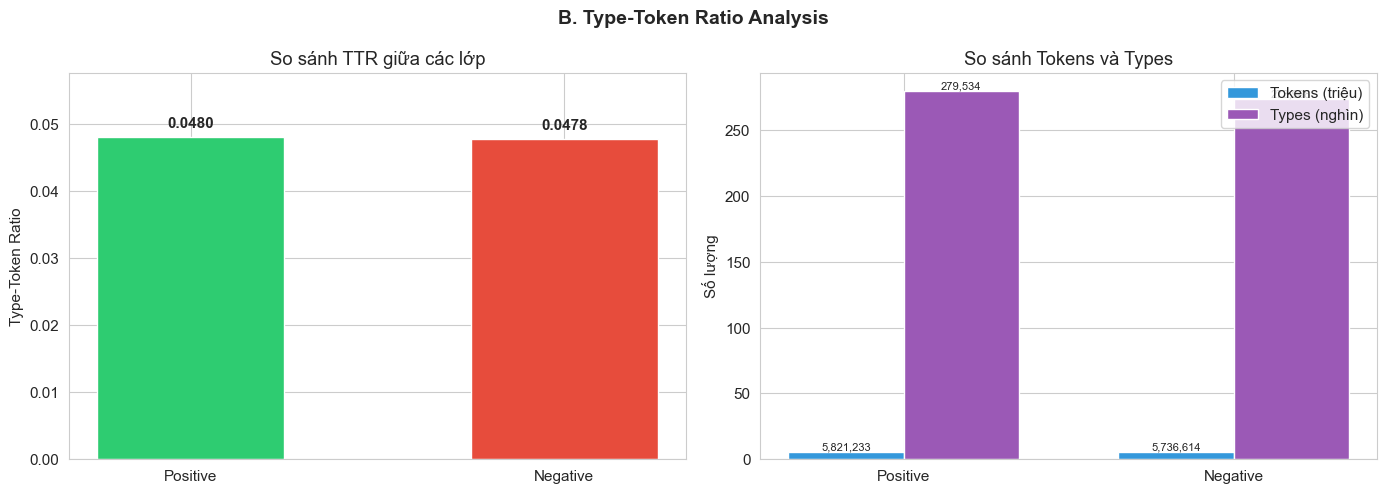

In [11]:
# TRỰC QUAN HÓA TTR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('B. Type-Token Ratio Analysis', fontsize=14, fontweight='bold')

# Bar chart so sánh TTR
ax1 = axes[0]
classes = ['Positive', 'Negative']
ttrs = [ttr_positive, ttr_negative]
colors_ttr = ['#2ecc71', '#e74c3c']
bars = ax1.bar(classes, ttrs, color=colors_ttr, edgecolor='white', width=0.5)
ax1.set_title('So sánh TTR giữa các lớp')
ax1.set_ylabel('Type-Token Ratio')
ax1.set_ylim(0, max(ttrs) * 1.2)
for bar, ttr in zip(bars, ttrs):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
             f'{ttr:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Grouped bar chart: Tokens vs Types
ax2 = axes[1]
x = np.arange(2)
width = 0.35
bars1 = ax2.bar(x - width/2, [tokens_pos/1e6, tokens_neg/1e6], width, label='Tokens (triệu)', color='#3498db')
bars2 = ax2.bar(x + width/2, [types_pos/1e3, types_neg/1e3], width, label='Types (nghìn)', color='#9b59b6')
ax2.set_ylabel('Số lượng')
ax2.set_title('So sánh Tokens và Types')
ax2.set_xticks(x)
ax2.set_xticklabels(classes)
ax2.legend()

# Thêm label
for bar, val in zip(bars1, [tokens_pos, tokens_neg]):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
             f'{val:,}', ha='center', va='bottom', fontsize=8, rotation=0)
for bar, val in zip(bars2, [types_pos, types_neg]):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
             f'{val:,}', ha='center', va='bottom', fontsize=8, rotation=0)

plt.tight_layout()
plt.show()

**Nhận xét**

#### 1. Phân tích số liệu thực tế
* **Lớp Positive:** Đạt chỉ số TTR là **0.0480** với 279,534 từ duy nhất trên tổng số hơn 5.8 triệu từ.
* **Lớp Negative:** Đạt chỉ số TTR là **0.0478** với 273,968 từ duy nhất trên tổng số khoảng 5.7 triệu từ.
* **Toàn bộ tập dữ liệu:** Chỉ số TTR tổng thể là **0.0380**.

#### 2. Nhận xét về độ phong phú từ vựng
* **Sự tương đồng giữa các lớp:** Chỉ số TTR của hai lớp Positive và Negative gần như tương đương nhau (chênh lệch chỉ **0.0002**). Điều này cho thấy sự đa dạng về vốn từ được sử dụng trong cả bài đánh giá tích cực và tiêu cực là **đồng nhất**. Không có lớp nào thể hiện sự vượt trội về độ phong phú ngôn từ.
* **Đặc điểm tập dữ liệu lớn:** Chỉ số TTR ở cả hai lớp đều khá thấp (~4.8%). Đây là hiện tượng bình thường trong xử lý ngôn ngữ tự nhiên khi làm việc với tập dữ liệu quy mô lớn. 
    * Với hơn **11.5 triệu tokens**, các từ thông dụng (stopwords) lặp lại với tần suất cực cao, làm giảm tỉ lệ từ duy nhất.
* **Hiệu ứng giảm TTR tổng thể:** Chỉ số TTR của toàn bộ tập dữ liệu (0.0380) thấp hơn TTR của từng lớp riêng biệt. Điều này phản ánh quy luật ngôn ngữ: khi kích thước mẫu tăng lên, số lượng từ mới (types) xuất hiện sẽ chậm lại so với tốc độ tăng của tổng số từ (tokens).

#### 3. Kết luận
Kết quả TTR khẳng định rằng tập dữ liệu có **tính cân bằng cao** không chỉ về số lượng mẫu mà còn về đặc điểm phân bố từ vựng. Tuy nhiên, để tăng cường hiệu quả cho các mô hình phân loại sau này, việc thực hiện **Stopwords Removal** là cần thiết để loại bỏ các từ lặp lại nhiều nhưng ít giá trị thông tin, từ đó làm nổi bật hơn các "keywords" mang sắc thái cảm xúc đặc trưng.

## Part C - Phân tích Phân phối Zipf

Định luật Zipf phát biểu rằng: trong ngôn ngữ tự nhiên, tần suất của một từ tỉ lệ nghịch với hạng (rank) của nó.

**Công thức**: f(r) ∝ 1/r^α

Trong đó:
- f(r): tần suất của từ có hạng r
- r: hạng của từ (1 = phổ biến nhất)
- Trong ngôn ngữ tự nhiên α ≈ 1 

In [12]:
def get_zipf_data(word_freq):
    """
    Chuẩn bị dữ liệu cho phân tích Zipf.
    Returns: ranks, frequencies
    """
    # Sắp xếp theo tần suất giảm dần
    sorted_freq = sorted(word_freq.values(), reverse=True)
    ranks = np.arange(1, len(sorted_freq) + 1)
    frequencies = np.array(sorted_freq)
    return ranks, frequencies

# Tính cho toàn bộ dữ liệu
word_freq_all_nostop = get_word_freq(df['review'], remove_stopwords=False)
ranks_all, freqs_all = get_zipf_data(word_freq_all_nostop)

# Tính cho từng lớp
word_freq_pos_nostop = get_word_freq(df[df['sentiment'] == 'positive']['review'], remove_stopwords=False)
word_freq_neg_nostop = get_word_freq(df[df['sentiment'] == 'negative']['review'], remove_stopwords=False)

ranks_pos, freqs_pos = get_zipf_data(word_freq_pos_nostop)
ranks_neg, freqs_neg = get_zipf_data(word_freq_neg_nostop)

print(f'Số từ unique:')
print(f'  - Toàn bộ: {len(word_freq_all_nostop):,} từ')
print(f'  - Positive: {len(word_freq_pos_nostop):,} từ')
print(f'  - Negative: {len(word_freq_neg_nostop):,} từ')

Số từ unique:
  - Toàn bộ: 438,729 từ
  - Positive: 279,534 từ
  - Negative: 273,968 từ


In [13]:
def fit_zipf(ranks, frequencies):
    """
    Ước lượng hệ số Zipf alpha bằng linear regression trên log-log scale.
    """
    log_ranks = np.log10(ranks)
    log_freqs = np.log10(frequencies)
    
    # Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(log_ranks, log_freqs)
    
    return -slope, intercept, r_value**2  # alpha = -slope

# Ước lượng alpha cho từng tập
alpha_all, intercept_all, r2_all = fit_zipf(ranks_all, freqs_all)
alpha_pos, intercept_pos, r2_pos = fit_zipf(ranks_pos, freqs_pos)
alpha_neg, intercept_neg, r2_neg = fit_zipf(ranks_neg, freqs_neg)

zipf_table = pd.DataFrame({
    'Dataset': ['Toàn bộ', 'Positive', 'Negative'],
    'alpha (Zipf exponent)': [f'{alpha_all:.4f}', f'{alpha_pos:.4f}', f'{alpha_neg:.4f}'],
    'R^2 (goodness of fit)': [f'{r2_all:.4f}', f'{r2_pos:.4f}', f'{r2_neg:.4f}']
})
print(zipf_table.to_string(index=False))
print()

 Dataset alpha (Zipf exponent) R^2 (goodness of fit)
 Toàn bộ                1.1685                0.9493
Positive                1.1489                0.9530
Negative                1.1330                0.9504



**Nhận xét:**
- Hệ số $\alpha \approx 1.1685$ đối với toàn bộ tập dữ liệu, lớn hơn một chút so với lý thuyết Zipf chuẩn ($\alpha = 1.0$). Điều này chỉ ra rằng tần suất từ vựng trong tập dữ liệu này giảm nhanh hơn một chút so với kỳ vọng lý thuyết.
- Hệ số xác định $R^2 = 0.9493$ (và $>0.95$ cho các tập Positive/Negative) là những con số rất cao. Điều này khẳng định mô hình hồi quy tuyến tính trên thang đo log-log vô cùng phù hợp, minh chứng tập dữ liệu IMDB tuân thủ chặt chẽ quy luật phân phối tần suất từ.

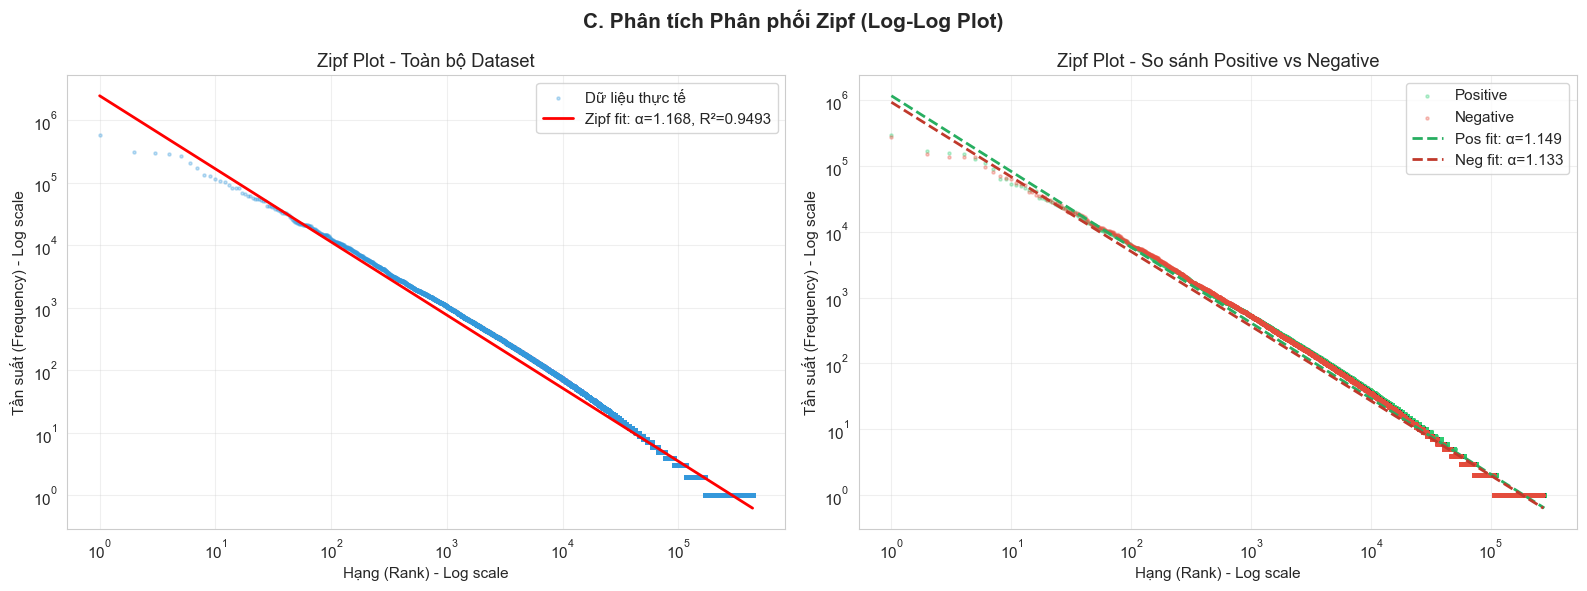

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('C. Phân tích Phân phối Zipf (Log-Log Plot)', fontsize=15, fontweight='bold')

# Plot 1: Toàn bộ dữ liệu 
ax1 = axes[0]
ax1.scatter(ranks_all, freqs_all, alpha=0.3, s=5, c='#3498db', label='Dữ liệu thực tế')

# Đường fit Zipf
zipf_fit_all = 10**intercept_all * (ranks_all ** (-alpha_all))
ax1.plot(ranks_all, zipf_fit_all, 'r-', linewidth=2, 
         label=f'Zipf fit: α={alpha_all:.3f}, R²={r2_all:.4f}')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Hạng (Rank) - Log scale')
ax1.set_ylabel('Tần suất (Frequency) - Log scale')
ax1.set_title('Zipf Plot - Toàn bộ Dataset')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Plot 2: So sánh Positive vs Negative 
ax2 = axes[1]
ax2.scatter(ranks_pos, freqs_pos, alpha=0.3, s=5, c='#2ecc71', label='Positive')
ax2.scatter(ranks_neg, freqs_neg, alpha=0.3, s=5, c='#e74c3c', label='Negative')

# Đường fit
zipf_fit_pos = 10**intercept_pos * (ranks_pos ** (-alpha_pos))
zipf_fit_neg = 10**intercept_neg * (ranks_neg ** (-alpha_neg))
ax2.plot(ranks_pos, zipf_fit_pos, color='#27ae60', linewidth=2, linestyle='--',
         label=f'Pos fit: α={alpha_pos:.3f}')
ax2.plot(ranks_neg, zipf_fit_neg, color='#c0392b', linewidth=2, linestyle='--',
         label=f'Neg fit: α={alpha_neg:.3f}')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Hạng (Rank) - Log scale')
ax2.set_ylabel('Tần suất (Frequency) - Log scale')
ax2.set_title('Zipf Plot - So sánh Positive vs Negative')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Nhận xét:**

**1. Đối với toàn bộ tập dữ liệu**
* **Sự tuân thủ quy luật Zipf:** Ở dải thứ hạng trung bình và thấp (phần giữa và đuôi đồ thị), các điểm dữ liệu thực tế tạo thành một đường thẳng tuyến tính đi xuống bám rất sát đường dự đoán. Điều này chứng tỏ tập dữ liệu IMDB tuân thủ khá tốt quy luật phân phối tự nhiên.
* **Hiện tượng gãy khúc ở nhóm Top đầu:** Ở những từ có thứ hạng cao nhất, tần suất thực tế có xu hướng hơi chệch so với đường dự đoán tuyến tính.
* **Hệ số $\alpha$:** Đường fit có độ dốc $\alpha = 1.1685$. Con số này lớn hơn 1 cho thấy tần suất từ vựng trong tập dữ liệu này suy giảm khá nhanh theo thứ hạng.

**2. So sánh giữa hai lớp Positive và Negative**
* **Sự tương đồng tuyệt đối:** Đường phân phối tần suất của lớp đánh giá tích cực và tiêu cực gần như xếp chồng lên nhau hoàn toàn trên toàn bộ trục.
* **Hệ số độ dốc:** Cả hai lớp có hệ số $\alpha$ cực kỳ sát nhau ($\alpha$ positive = 1.1489, $\alpha$ negative = 1.1330).
* **Kết luận rút ra:** Cấu trúc phân bổ từ vựng và thói quen sử dụng tần suất từ của người dùng là hoàn toàn giống nhau, bất kể họ đang khen hay chê bộ phim. Do đó, đặc trưng về "tần suất phân bổ tổng thể" (như phân phối Zipf) mang ý nghĩa khảo sát thống kê ngôn ngữ học, nhưng **không có giá trị đóng góp cho mô hình học máy** trong việc phân loại cảm xúc văn bản.

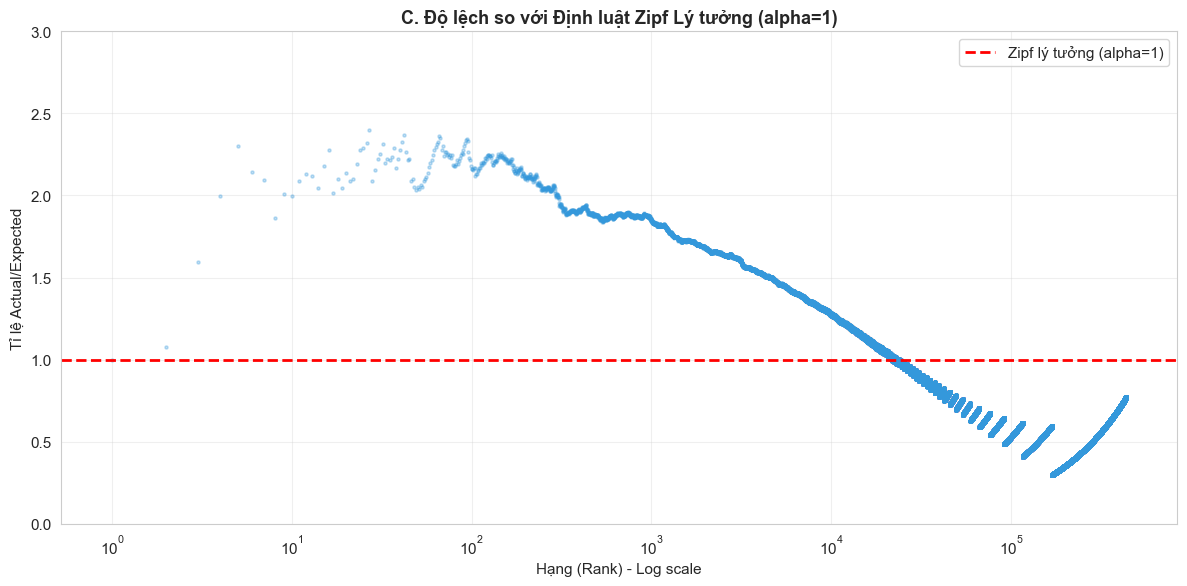

In [15]:
# PHÂN TÍCH ĐỘ LỆCH SO VỚI ĐỊNH LUẬT ZIPF
fig, ax = plt.subplots(figsize=(12, 6))

ideal_zipf = freqs_all[0] / ranks_all  # f(r) = f(1) / r

# Tính tỉ lệ actual/expected
ratio = freqs_all / ideal_zipf

ax.scatter(ranks_all, ratio, alpha=0.3, s=5, c='#3498db')
ax.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Zipf lý tưởng (alpha=1)')
ax.set_xscale('log')
ax.set_xlabel('Hạng (Rank) - Log scale')
ax.set_ylabel('Tỉ lệ Actual/Expected')
ax.set_title('C. Độ lệch so với Định luật Zipf Lý tưởng (alpha=1)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 3)

plt.tight_layout()
plt.show()

**Nhận xét:**

Biểu đồ trực quan hóa tỉ lệ giữa tần suất thực tế và tần suất kỳ vọng cho thấy tập dữ liệu IMDB có sự phân bổ từ vựng lệch khá rõ so với định luật Zipf lý tưởng ($\alpha=1$). Cụ thể:

* **Nhóm từ phổ biến và trung bình (Hạng từ $10^1$ đến $10^4$):** Tỉ lệ Actual/Expected vọt lên lớn hơn 1 rất nhiều (đỉnh điểm > 2.0). Điều này cho thấy các từ vựng trong nhóm này xuất hiện với tần suất **dày đặc hơn nhiều** so với lý thuyết. Đây là đặc trưng thường thấy ở các tập dữ liệu mang tính chuyên ngành (domain-specific corpus); do cùng chủ đề bình luận phim, người dùng có xu hướng xài đi xài lại một lượng từ vựng cốt lõi nhất định.
* **Điểm cắt:** Đường dữ liệu thực tế cắt ngang đường Zipf lý tưởng (màu đỏ đứt nét tại $y = 1$) ở khoảng thứ hạng $10^4$ đến $2 \times 10^4$. Tại vùng thứ hạng này, tần suất xuất hiện của các từ khá khớp với dự đoán của mô hình chuẩn.
* **Nhóm từ hiếm / Đuôi dài (Hạng trên $2 \times 10^4$):** Tỉ lệ lao dốc mạnh xuống dưới mức 1 và liên tục giảm sâu. Lượng từ ít gặp như tên riêng phụ, từ hiếm, hoặc lỗi chính tả xuất hiện **ít hơn đáng kể** so với kỳ vọng của Zipf lý tưởng.

**Kết luận:** Tập dữ liệu IMDB có tính tập trung từ vựng cục bộ rất cao. Từ vựng cốt lõi về chủ đề điện ảnh chiếm ưu thế tuyệt đối, trong khi lượng từ hiếm bị thu hẹp nhanh chóng, khiến phân phối thực tế phình ra ở giữa và hụt đi ở phần đuôi so với ngôn ngữ tự nhiên tổng quát.